### Nota: IA utilizada para sintaxis de plots.

### Convierto variables como definimos en SQL

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)

orders = pd.read_csv("../data/orders.csv", parse_dates=[
    "checkout_timestamp", "merchant_notification_time",
    "rider_notification_time", "rider_arrival_time",
    "out_for_delivery_time", "delivery_timestamp"
])

# Columnas derivadas útiles para el EDA
orders["total_delivery_min"] = (
    orders.delivery_timestamp - orders.checkout_timestamp
).dt.total_seconds() / 60

orders["rider_wait_min"] = (
    orders.out_for_delivery_time - orders.rider_arrival_time
).dt.total_seconds() / 60

orders["obs_prep_min"] = (
    orders.out_for_delivery_time - orders.merchant_notification_time
).dt.total_seconds() / 60

orders["delivery_leg_min"] = (
    orders.delivery_timestamp - orders.out_for_delivery_time
).dt.total_seconds() / 60

orders["rider_dispatch_min"] = (
    orders.rider_arrival_time - orders.rider_notification_time
).dt.total_seconds() / 60

orders["checkout_hour"] = orders.checkout_timestamp.dt.hour
orders["rider_waited"] = orders.rider_wait_min > 2

print(orders.shape)
orders.head()

(10000, 18)


,order_id,merchant_id,zone_id,checkout_timestamp,order_category,distance_km,merchant_notification_time,rider_notification_time,rider_arrival_time,out_for_delivery_time,delivery_timestamp,total_delivery_min,rider_wait_min,obs_prep_min,delivery_leg_min,rider_dispatch_min,checkout_hour,rider_waited
0,ORD000000,M073,Z2,2026-01-02 14:39:00,pharmacy,5.73,2026-01-02 14:40:33.223568,2026-01-02 14:40:43.138938,2026-01-02 15:00:05.472426,2026-01-02 15:00:05.472426,2026-01-02 15:26:21.234352,47.353906,0.000000,19.537481,26.262699,19.372225,14,False
1,ORD000001,M034,Z6,2026-01-26 15:36:00,food,1.40,2026-01-26 15:37:00.769170,2026-01-26 15:37:11.015888,2026-01-26 15:47:52.534958,2026-01-26 16:04:29.678823,2026-01-26 16:11:34.116646,35.568611,16.619064,27.481828,7.073964,10.691985,15,True
2,ORD000002,M055,Z4,2026-01-13 21:34:00,pharmacy,1.27,2026-01-13 21:35:51.229762,2026-01-13 21:36:00.630285,2026-01-13 21:57:01.063661,2026-01-13 21:57:01.063661,2026-01-13 22:05:00.557288,31.009288,0.000000,21.163898,7.991560,21.007223,21,False
3,ORD000003,M043,Z8,2026-02-27 21:07:00,supermarket,1.38,2026-02-27 21:08:28.428927,2026-02-27 21:09:29.525386,2026-02-27 21:24:25.831582,2026-02-27 21:25:11.984323,2026-02-27 21:33:43.207229,26.720120,0.769212,16.725923,8.520382,14.938437,21,False
4,ORD000004,M067,Z1,2026-02-18 16:25:00,food,3.36,2026-02-18 16:26:57.292296,2026-02-18 16:27:41.054271,2026-02-18 16:40:10.707273,2026-02-18 16:41:31.091148,2026-02-18 16:56:17.863141,31.297719,1.339731,14.563314,14.779533,12.494217,16,False


### Check de Nulos

In [11]:
print("Nulos por columna:")
print(orders.isnull().sum())
print(f"\nÓrdenes con tiempos negativos: {(orders.total_delivery_min < 0).sum()}")

Nulos por columna:
order_id                      0
merchant_id                   0
zone_id                       0
checkout_timestamp            0
order_category                0
distance_km                   0
merchant_notification_time    0
rider_notification_time       0
rider_arrival_time            0
out_for_delivery_time         0
delivery_timestamp            0
total_delivery_min            0
rider_wait_min                0
obs_prep_min                  0
delivery_leg_min              0
rider_dispatch_min            0
checkout_hour                 0
rider_waited                  0
dtype: int64

Órdenes con tiempos negativos: 0


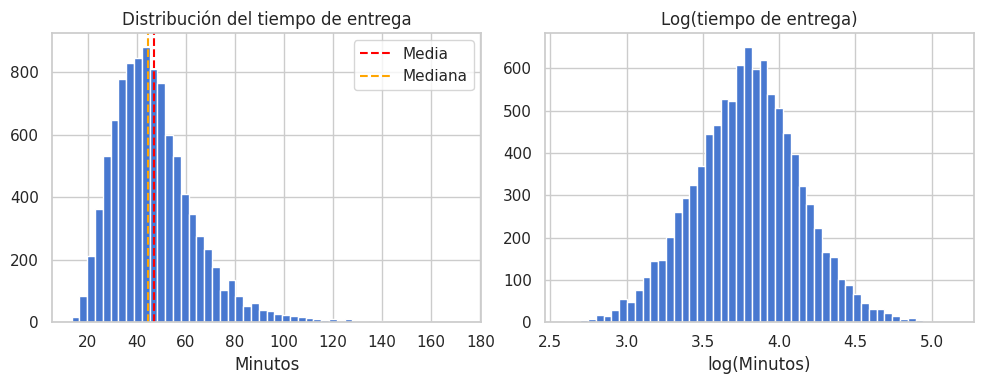

count    10000.0
mean        47.0
std         17.0
min         13.4
25%         35.2
50%         44.5
75%         55.4
max        172.4
Name: total_delivery_min, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(orders.total_delivery_min, bins=50)
axes[0].set_title("Distribución del tiempo de entrega")
axes[0].set_xlabel("Minutos")
axes[0].axvline(orders.total_delivery_min.mean(), color="red", linestyle="--", label="Media")
axes[0].axvline(orders.total_delivery_min.median(), color="orange", linestyle="--", label="Mediana")
axes[0].legend()

axes[1].hist(np.log(orders.total_delivery_min), bins=50)
axes[1].set_title("Log(tiempo de entrega)")
axes[1].set_xlabel("log(Minutos)")

plt.tight_layout()
plt.show()

print(orders.total_delivery_min.describe().round(1))

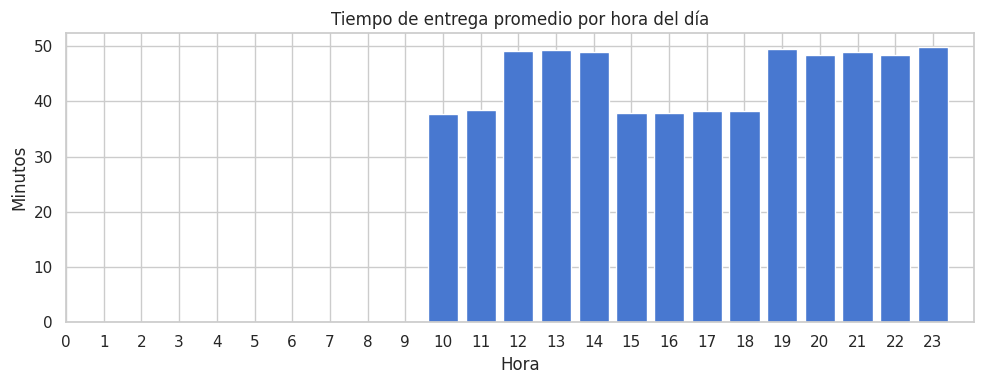

In [13]:
hourly = orders.groupby("checkout_hour")["total_delivery_min"].mean()

plt.figure()
plt.bar(hourly.index, hourly.values)
plt.title("Tiempo de entrega promedio por hora del día")
plt.xlabel("Hora")
plt.ylabel("Minutos")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

Las horas pico toman ~10 minutos más en promedio para sus entregas.

<Figure size 1000x400 with 0 Axes>

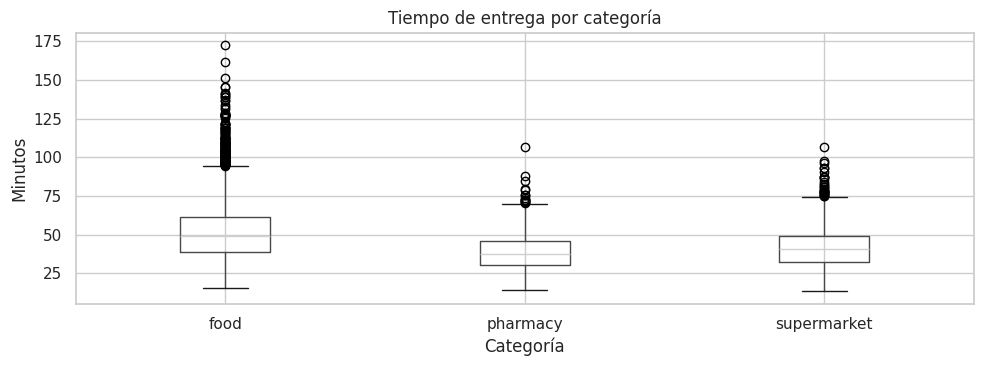

In [14]:
plt.figure()
orders.boxplot(column="total_delivery_min", by="order_category")
plt.suptitle("")
plt.title("Tiempo de entrega por categoría")
plt.xlabel("Categoría")
plt.ylabel("Minutos")
plt.tight_layout()
plt.show()

Comida es el segmento que más toma, con los outliers más fuertes, seguido por supermercado y luego farmacia.

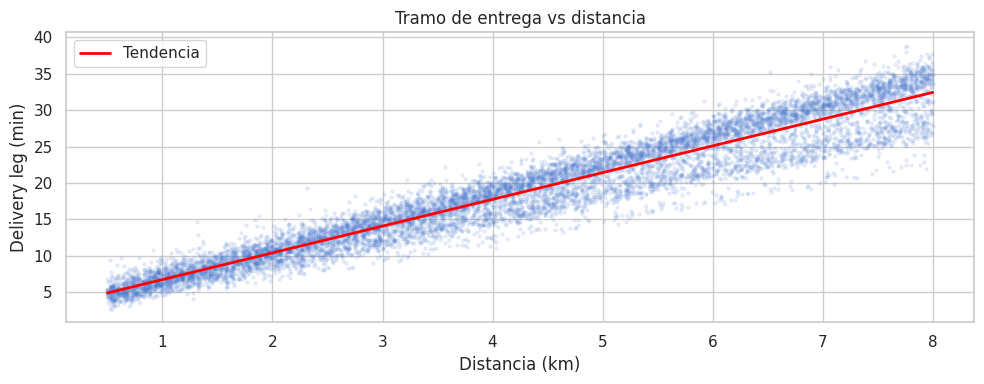

In [15]:
plt.figure()
plt.scatter(orders.distance_km, orders.delivery_leg_min, alpha=0.1, s=5)
plt.title("Tramo de entrega vs distancia")
plt.xlabel("Distancia (km)")
plt.ylabel("Delivery leg (min)")

# Línea de tendencia
z = np.polyfit(orders.distance_km, orders.delivery_leg_min, 1)
p = np.poly1d(z)
x_line = np.linspace(0.5, 8, 100)
plt.plot(x_line, p(x_line), color="red", linewidth=2, label="Tendencia")
plt.legend()
plt.tight_layout()
plt.show()

Al rider le toma más llegar al destino mientras más lejos está el local.

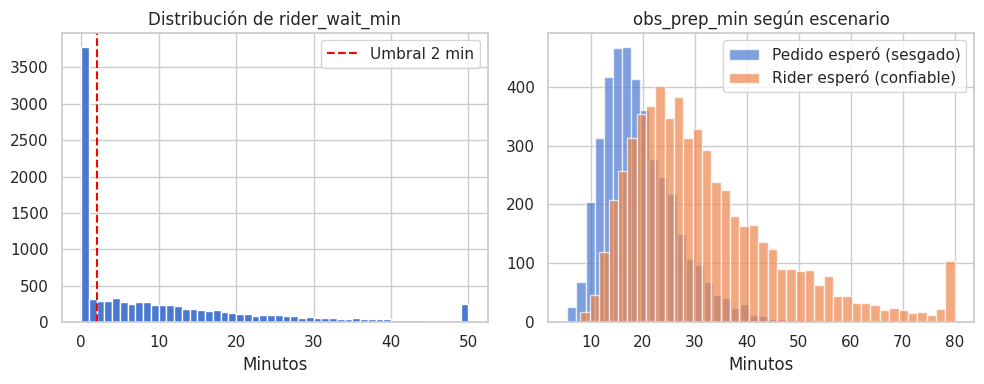

Escenario A (pedido esperó): 41.0%
Escenario B (rider esperó):  59.0%


In [20]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(orders.rider_wait_min.clip(0, 50), bins=50, edgecolor="white")
axes[0].axvline(2, color="red", linestyle="--", label="Umbral 2 min")
axes[0].set_title("Distribución de rider_wait_min")
axes[0].set_xlabel("Minutos")
axes[0].legend()

# Prep time observable: con y sin rider_waited
axes[1].hist(orders[~orders.rider_waited].obs_prep_min.clip(0, 80),
             bins=40, alpha=0.7, label="Pedido esperó (sesgado)", edgecolor="white")
axes[1].hist(orders[orders.rider_waited].obs_prep_min.clip(0, 80),
             bins=40, alpha=0.7, label="Rider esperó (confiable)", edgecolor="white")
axes[1].set_title("obs_prep_min según escenario")
axes[1].set_xlabel("Minutos")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Escenario A (pedido esperó): {(~orders.rider_waited).mean()*100:.1f}%")
print(f"Escenario B (rider esperó):  {orders.rider_waited.mean()*100:.1f}%")

Izquierda, rider_wait_min:
El pico masivo en 0 corresponde al Escenario A (pedido listo antes que el rider).
La cola derecha son los casos donde el rider esperó (Escenario B).
El umbral de 2 min (línea roja) separa ambos escenarios.

Derecha, obs_prep_min por escenario:

Escenario A (azul): distribución más estrecha y centrada más a la izquierda.
obs_prep_min subestima porque el pedido estuvo listo antes de que llegara el rider,
pero el tiempo medido incluye la espera del pedido hasta el retiro.
NO usamos estos valores para estimar prep time del merchant.

Escenario B (naranja): distribución más amplia con cola derecha más pronunciada.
obs_prep_min ~= prep time real porque el rider llegó y tuvo que esperar.
SOLO estos valores alimentan merchant_avg_prep_min y merchant_std_prep_min.

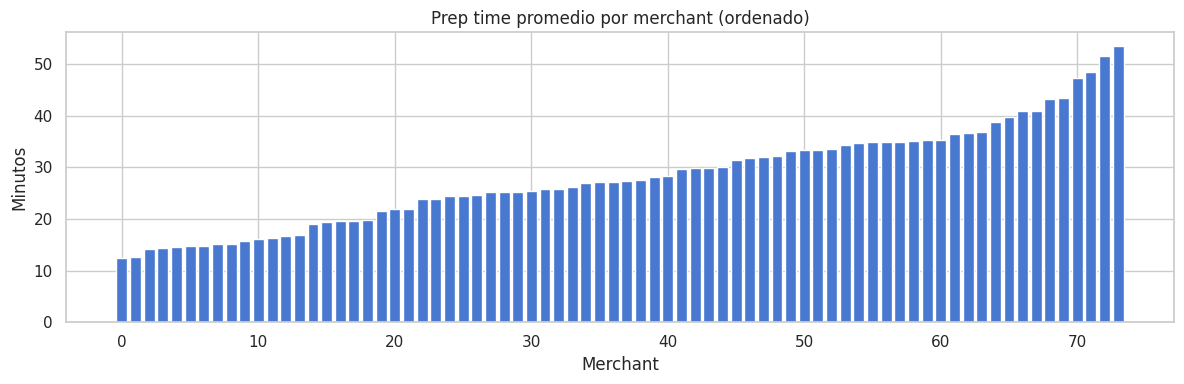

In [22]:
merchant_stats = (
    orders[orders.rider_waited]
    .groupby("merchant_id")["obs_prep_min"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

plt.figure(figsize=(12, 4))
plt.bar(range(len(merchant_stats)), merchant_stats["mean"])
plt.title("Prep time promedio por merchant (ordenado)")
plt.xlabel("Merchant")
plt.ylabel("Minutos")
plt.tight_layout()
plt.show()

Hay merchants que son consistentemente más lentos que otros.

In [23]:
zone_stats = orders.groupby("zone_id").agg(
    delivery_leg_avg=("delivery_leg_min", "mean"),
    rider_dispatch_avg=("rider_dispatch_min", "mean")
).round(1)

print(zone_stats.sort_values("delivery_leg_avg"))

         delivery_leg_avg  rider_dispatch_avg
zone_id                                      
Z3                   15.5                13.0
Z8                   17.7                15.0
Z7                   18.6                15.5
Z2                   19.3                16.1
Z1                   19.7                16.5
Z4                   19.7                16.7
Z5                   19.7                16.5
Z6                   20.0                17.3


El efecto del tráfico resulta en zonas en las que se demora más en los tramos del rider.

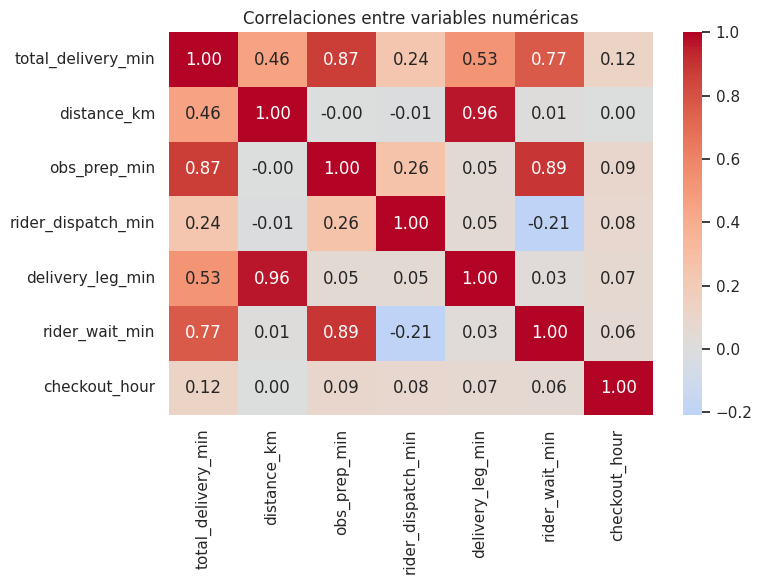

In [24]:
num_cols = [
    "total_delivery_min", "distance_km", "obs_prep_min",
    "rider_dispatch_min", "delivery_leg_min",
    "rider_wait_min", "checkout_hour"
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    orders[num_cols].corr().round(2),
    annot=True, cmap="coolwarm", center=0, fmt=".2f"
)
plt.title("Correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()